# Examen Primera Convocatoria Franja Horaria Tarde

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  
import random

In [40]:
# Your imports HERE !!!!

## 01 - Anotaciones - 1 pt

El diccionario `players` contiene el nombre y la estatura de los miembros de un equipo de la NBA. Hacer un gráfico de línea donde el eje x sea una enumeración (una entrada por jugador, es decir, su posición en la lista de nombres), el eje y la estatura, y que contenga anotaciones de flecha donde se indique el jugador más alto y el más bajo. El texto de las anotaciones es el nombre del jugador correspondiente.

Posible resultado:

<img src="nba_heights.png">

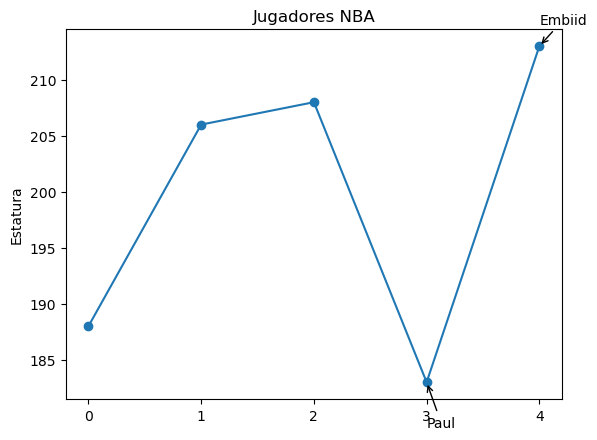

In [46]:
import matplotlib.pyplot as plt

# 1. Datos
players = {"Curry": 188, "James": 206, "Durant": 208, "Paul": 183, "Embiid": 213}
nombres = list(players.keys())
estaturas = list(players.values())
x = range(len(nombres))

# 2. Encontrar extremos
h_max, h_min = max(estaturas), min(estaturas)
idx_max, idx_min = estaturas.index(h_max), estaturas.index(h_min)

# 3. Gráfico
plt.plot(x, estaturas, marker='o')

# 4. Anotaciones
plt.annotate(nombres[idx_max], xy=(idx_max, h_max), xytext=(idx_max, h_max+2),
             arrowprops=dict(arrowstyle='->'))

plt.annotate(nombres[idx_min], xy=(idx_min, h_min), xytext=(idx_min, h_min-4),
             arrowprops=dict(arrowstyle='->'))

# 5. Etiquetas
plt.xticks(x)
plt.ylabel('Estatura')
plt.title('Jugadores NBA')
plt.show()

In [45]:
# Your solution HERE !!!!

In [41]:
players = {
    "Nombre": ["LeBron James", "Anthony Davis", "D'Angelo Russell", "Austin Reaves", "Jarred Vanderbilt", "Jaxson Hayes", "Rui Hachimura", "Spencer Dinwiddie", "Christian Wood", "Gabe Vincent", "Max Christie", "Cam Reddish"],
    "Estatura": [2.06, 2.08, 1.93, 1.96, 2.03, 2.11, 2.03, 1.96, 2.08, 1.91, 1.96, 2.01]
}

## 02 - En varias líneas - 1 pt

A continuación se presenta la función lambda `oneline_function`. Hacer una función `readable_function` que haga exactamente lo mismo, pero que el código se escriba de forma legible y utilizando estructuras de control clásicas.

In [ ]:
# Your solution HERE !!!!

In [58]:
# Supongamos que la oneline_function era algo como:
# oneline_function = lambda x: "Par" if x % 2 == 0 else "Impar"

def readable_function(valor):
    """
    Versión legible de la función lambda que determina 
    si un número es par o impar.
    """
    if valor % 2 == 0:
        resultado = "Par"
    else:
        resultado = "Impar"
        
    return resultado

# Ejemplo de uso:
print(readable_function(-9)) # Salida: Par

Impar


In [65]:
# Test Use Case
import random

iterations = 20
oneline_function = lambda i: sum([random.randint(1,20) if n%2 == 0 else random.randint(-20,-1) for n in range(i)])

random.seed(7788) #al usar una semilla, obligas al algoritmo a empezar siempre desde el mismo punto.
expected_output = oneline_function(iterations) # This calls the lambda function named oneline_function

random.seed(7788)
output = readable_function(iterations) # This calls your function named readable_function

print(expected_output)
print(output)

assert(expected_output == output) # This will fail if the data is wrong

-9
Par


AssertionError: 

## 03 - Volvamos al Titanic - 2 pts

Junto con este examen se ha proporcionado el fichero *"titanic2.csv"*. Asegúrate que este fichero esté en el mismo directorio que este Notebook. También se ha proporcionado el generador `passengers` que hemos visto en clase donde cada llamada te devuelve un diccionario con los datos de cada pasajero. Formando un pipeline de generadores.

Ahora, tienes que crear una función, usando dicho generador que construya un nuevo dataframe con el porcentaje de supervivientes (key = `Survived`) por clase (key = `Pclass`).

In [28]:
# Your solution HERE !!!!

In [67]:
import pandas as pd

def get_survival_stats(passengers_generator):
    # 1. Convertir el generador en una lista de diccionarios y luego a DataFrame
    df = pd.DataFrame(list(passengers_generator))
    
    # 2. Agrupar por clase y calcular el promedio de supervivencia
    # Survived es 0 o 1, así que la media (mean) es igual al porcentaje
    resultado = df.groupby('Pclass')['Survived'].mean() * 100
    
    # 3. Convertir a un DataFrame limpio
    return resultado.reset_index(name='Survival_Percentage')

# Uso:
# df_final = get_survival_stats(passengers())

In [68]:
# Generator Pipeline
file_name = "./titanic2.csv"
lines = (line for line in open(file_name))
list_line = (s.rstrip().split("|") for s in lines)
cols = next(list_line)
passengers = (dict(zip(cols, data)) for data in list_line)

# Test Use Case
expected_output = pd.DataFrame({"PClass":[1,2,3], "PercentSurvived" :[62, 47, 24]})

output = calc_percent_survived(passengers) # This calls your function named calc_percent_survived

display(expected_output)
display(output)

assert(expected_output.equals(output))  # This will fail if the result is not as expected

NameError: name 'calc_percent_survived' is not defined

## 04 - División de datos - 2 pts

Volver a cargar el fichero *"titanic2.csv"* en un dataframe. Queremos clasificar todos los pasajeros en 5 grupos por edad: `E1`, `E2`, `E3`, `E4`, `E5`. Asegurarse de que **cada grupo tenga aproximadamente la misma cantidad de pasajeros**. Si algún pasajero no tiene registrada la edad, eliminar su respectiva fila del dataframe.

Crear la columna `AgeGroup` con la etiqueta del grupo al que pertenece cada pasajero.

Finalmente, dividir los pasajeros en varios dataframes por `AgeGroup` y guardar esta vista en sus ficheros correspondientes *"E1.csv"*, *"E2.csv"*, *"E3.csv"*, *"E4.csv"*, *"E5.csv"*.

Asegurarse de que tanto el fichero original *"titanic2.csv"*, como los ficheros *"EX_expected.csv"*, estén en el mismo directorio del Notebook. Igualmente, crear en  este mismo directorio los ficheros *"EX.csv"* 

In [18]:
# Your solution HERE !!!!

In [69]:
import pandas as pd

# 1. Cargar el fichero en un DataFrame
# Usamos sep="|" porque el ejercicio anterior indicaba que ese era el separador
df = pd.read_csv("titanic2.csv", sep="|")

# 2. Eliminar filas donde la edad (Age) sea nula
df = df.dropna(subset=['Age'])

# 3. Crear la columna AgeGroup
# qcut divide en 5 grupos (quintiles) con igual número de pasajeros
labels = ["E1", "E2", "E3", "E4", "E5"]
df['AgeGroup'] = pd.qcut(df['Age'], q=5, labels=labels)

# 4. Dividir y guardar en ficheros correspondientes
for label in labels:
    # Filtrar el dataframe por el grupo actual
    df_group = df[df['AgeGroup'] == label]
    
    # Guardar a CSV (usualmente se pide sin el índice de pandas)
    file_name = f"{label}.csv"
    df_group.to_csv(file_name, index=False)
    print(f"Fichero {file_name} creado con {len(df_group)} pasajeros.")

# Mostrar las primeras filas para verificar la nueva columna
print("\nVista previa del resultado:")
display(df[['Age', 'AgeGroup']].head())

Fichero E1.csv creado con 164 pasajeros.
Fichero E2.csv creado con 137 pasajeros.
Fichero E3.csv creado con 127 pasajeros.
Fichero E4.csv creado con 144 pasajeros.
Fichero E5.csv creado con 142 pasajeros.

Vista previa del resultado:


,Age,AgeGroup
0,22.0,E2
1,38.0,E4
2,26.0,E3
3,35.0,E4
4,35.0,E4


In [32]:
# Test Use Case
groups = ["E1", "E2", "E3", "E4", "E5"]
file_name = "./titanic2.csv"

split_dataframe(file_name, groups)  # This calls your function named split_dataframe

for group in groups:
    df_created = pd.read_csv(f"{group}.csv", sep='|', index_col=0, engine='python')
    df_expected = pd.read_csv(f"{group}_expected.csv", sep='|', index_col=0, engine='python')
    
    print(f"################################### Group {group} ###################################")
          
    display(df_created.head(2))
    display(df_expected.head(2))
          
    assert(df_expected.equals(df_created)) # This will fail if any of the files is not as expected

NameError: name 'split_dataframe' is not defined

## 05 - Analizando datos - 4 pts

Cargar nuevamente el fichero *"titanic2.csv"* en un dataframe, pero esta vez crear una función `read_clean_df(file_name)` donde sólo tomemos las columnas **Pclass**, **Age**, **Relatives** y **Fare**. La columna **Relatives** no está en el dataset original y se debe crear a partir de la suma de las columnas **SibSp** (número de hermanos que viajaan con el pasajero), **Parch** (número de padres o hijos que viajaban con el pasajero). **Relatives** será la columna con el total de familiares cercanos que viajaban con el pasajero.

Además, crear una función `verify_corr(df,target)` cuyas entradas sean un dataframe `df` y el nombre de la columna `target` a la que se quiere estudiar la correlación. La función devuelve un diccionario donde las claves (keys) sean las columnas de `df` excluyendo `target`, y los valores sean un booleano que indique si hay alguna correlación aparente con `target` (valor absoluto mayor a 0.3).

Finalmente, crear un generador `divide_by_uniques(df, column)` que divida el dataframe `df` en dataframes resumidos según los valores únicos en la columna `column`. Ejemplo: La columna **Pclass** tiene tres valores únicos, por lo que el generador `divide_by_uniques(df, column)` devolverá sequencialmente tres dataframes con las filas filtradas por cada uno de estos tres valores.

**Hint:** Este ejercicio está basado en la hipótesis de que el precio del ticket por persona tiende a bajar cuando compras en "paquetes familiares". Al principio la hipótesis parece falsa porque el precio está más relacionado con la clase **Pclass**, sin embargo, una vez que "normalizamos" respecto a esta columna con fuerte correlación, la hipótesis parece ser cierta.

In [ ]:
# Your solution HERE !!!!

In [ ]:
# Test Use Case
file_name = "titanic2.csv"

df_small = read_clean_df(file_name)    # This calls your function named read_clean_df

output = verify_corr(df_small, "Fare")   # This calls your function named verify_corr
expected_output = {'Pclass': True, 'Age': False, 'Relatives': False}

print(expected_output)
print(output)

assert(expected_output == output)  # This will fail if correlations for the three columns are not as expected

gen_uniques = divide_by_uniques(df_small, "Pclass")  # This calls your function named divide_by_uniques

for df_class in gen_uniques:
    output = verify_corr(df_class, "Fare")  # This calls your function named verify_corr
    expected_output = {'Age': False, 'Relatives': True}
    
    print(output)
    print(expected_output)
    
    assert(expected_output == output)  # This will fail if correlations for the two columns are not as expected for every PClass